***
# Homework 12: TensorFlow and Google Cloud Platform

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten, Amy Merkelz

**Date:** April 28th, 2024
***

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print( tf.__version__ )

2.16.1


## 1.) Warmup: Constructing a 3-tensor (2 points, spent $\approx$ 25 minutes)

**You may have noticed that the TensorFlow logo, seen in Figure 1 below, is a 2-dimensional depiction of a 3-dimensional orange structure, which casts shadows shaped like a “T” and an “F”, depending on the direction of the light. The structure is five “cells” tall, four wide and three deep.**

**Create a TensorFlow constant tensor `tflogo` with shape `5-by-4-by-3`. This tensor will represent the `5-by-4-by-3` volume that contains the orange structure depicted in the logo (said another way, the orange structure is inscribed in this `5-by-4-by-3` volume).** 

**Each cell of your tensor should correspond to one cell in this volume. Each entry of your tensor should be 1 if and only if the corresponding cell is part of the orange structure, and should be 0 otherwise.** 

**Looking at the logo, we see that the orange structure can be broken into 11 cubic cells, so your tensor tflogo should have precisely 11 non-zero entries. For the sake of consistency, the `(0, 3, 2)`-entry of your tensor (using 0-indexing) should correspond to the top rear corner of the structure where the cross of the “T” meets the top of the “F”.** 

**Note: if you look carefully, the shadows in the logo do not correctly reflect the orange structure—the shadow of the “T” is incorrectly drawn. Do not let this fool you!**

**Hint: you may find it easier to create a `numpy` array representing the structure first, then turn that numpy array into a TensorFlow constant.** 

**Second hint: as a sanity check, try printing your tensor. You should see a series of `4-by-3` matrices, as though you were looking at one horizontal slice of the tensor at a time, working your way from top to bottom.**

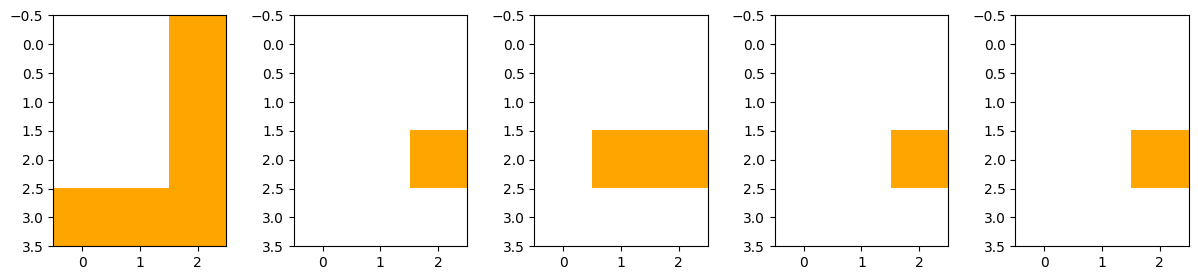

In [2]:
# we use the fact that the (0,3,2)-entry of the 3D array is the only one that is where
# correspond to the top rear corner of the structure 
# where the cross of the “T” meets the top of the “F”.

# top-most view gives us an "L" that points to the left
zero_layer = tf.constant(
[       [0, 0, 1], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 1], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [1, 1, 1]  # (0,3,0) (0,3,1) (0,3,2)
])

# removing the top-most layer, we only have the cube corresponding to the height of the structure
first_layer = tf.constant(
[       [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0]  # (0,3,0) (0,3,1) (0,3,2)
])

# removing the first layer, we have cube for the height of the structure, as well as the notch of the "F"
second_layer = tf.constant(
[       [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 1, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0]  # (0,3,0) (0,3,1) (0,3,2)
])

# removing the second layer, we only have the cube for the height of the structure
third_layer = tf.constant(
[       [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0]  # (0,3,0) (0,3,1) (0,3,2)
])

# removing the third layer, we only have the final cube for the height of the structure
fourth_layer = tf.constant(
[       [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0]  # (0,3,0) (0,3,1) (0,3,2)
])

cmap = mcolors.ListedColormap(['white', 'orange'])
fig, axs = plt.subplots(1, 5, figsize = (15, 3))
axs[0].imshow(zero_layer, cmap = cmap)
axs[1].imshow(first_layer, cmap = cmap)
axs[2].imshow(second_layer, cmap = cmap)
axs[3].imshow(third_layer, cmap = cmap)
axs[4].imshow(fourth_layer, cmap = cmap)

In [3]:
# We use the fact that the (0,3,2)-entry of the 3D array is the only one that is where
# correspond to the top rear corner of the structure 
# where the cross of the “T” meets the top of the “F”.
tflogo = tf.stack( [zero_layer, 
                    first_layer, 
                    second_layer, 
                    third_layer, 
                    fourth_layer], axis = 0)
print(tflogo.shape)

(5, 4, 3)


## 2.) Ordinary Least Squares Linear Regression (5 points, spent $\approx$ 45 minutes)

**This problem will walk you through building and fitting a simple linear regression model, expanding on the example from lecture. In particular, we will adapt the code from lecture to define a class `LinearModel` that encodes linear regression for p-dimensional data, instead of the 1-dimensional case from lecture. You are free to start from the lecture code, which is available in the demo notebook on the course webpage or canvas, or just copy-paste this (be mindful of weird indentation caused by copying from a pdf!):**

```python
class LinearModel(tf.Module):
    
    def __init__(self, name=None):
        super().__init__(name=name)
        self.W = tf.Variable([1.0], dtype=tf.float32, name="slope")
        self.b = tf.Variable([1.0], dtype=tf.float32, name="intercept")

    def __call__(self, x):
        return self.W * x + self.b
```

#### 1.

**Override the initialization method to take an optional argument `p`, and initialize `W` and `b` to be tensors with shapes `(p,)` and `(1,)`, respectively, with entries initialized to be independent standard normals.** 

**The argument `p` should default to `p=1` and your initialization method should raise an appropriate error in the event that this argument is not a positive integer.** 

**Note: in the Keras tutorials below, we’ll see a different way to do this using the `tf.keras.layers` submodule, which is expressly designed for specifying multilayer perceptrons and neural nets. For this problem, please just use TensorFlow Variable Tensor objects.**

#### 2.

**Implement an additional method `get_dimension` that takes no arguments (other than self) and returns the data dimension (i.e., the initialization argument `p`). You are free to store `p` as a class attribute or to simply read `p` from `self.W.shape`.**

#### 3.

**Implement the `__call__` method so that the input `x` is a `tf.Tensor` of shape `(n,p)`, where:**

* **`n` is a number of observations (not known ahead of time!).**

* **`p` is the dimension specified upon initialization.**

**That is, each row of `x` is a vector of `p` predictors. The output of the call should be a  `tf.Tensor` of shape `(n,)`, and should encode the prediction of the model applied to each row of `x`. There is no need to perform error checking for this method. We will leave it to TensorFlow to yell at us if x is of the wrong type or the wrong shape when we try to multiply it.** 

**Hint: you will be tempted to write something like `self.W * x + self.b`, but this will not work, owing to the shapes of `W` and `x`. Instead, look at the `tf.tensordot function` or use the matrix multiplication operator `@`.**

**As a sanity check, try running the following code snippet (this assumes that you have kept the names `W` and `b` for the slope and intercept; you’ll have to update it if you chose something different):**

```python
linear_model = LinearModel(p=3)
linear_model.W.assign([1.0,1.0,1.0])
linear_model.b.assign([1.0])
x = tf.constant([[0,1,2],[3,4,5]], dtype=tf.float32)
linear_model( x )
```

**The result should be a tensor that looks something like:**

```python
<tf.Tensor: shape=(2,), dtype=float32, numpy=array([ 4., 13.], dtype=float32)>
```

#### 4.

**Following the example from lecture, define a loss function loss that takes two arguments, `y_obsd` and `y_pred`, which are two `tf.Tensor` objects of the same shape `(n,)` for some positive integer `n`, and returns the mean squared error between the two vectors. That is, it computes:**

$$
\frac{1}{n}\bigg(\sum_{i=1}^{n} y^{(i)}_\text{obsd} - y^{(i)}_\text{pred} \bigg)^2
$$

**Note that the example from lecture uses `tf.reduce_sum`, so you’ll need to read the documentation to find out how to get a mean instead. There is no need to perform any error checking in this function.**

#### 5.

**Continuing to follow the example from lecture, define a function `train` that takes a `LinearModel` object, a `tf.Tensor` `X` with shape `(n,p)`, a `tf.Tensor` `y` with shape `(n,)` and a float `step_size` (i.e., the learning rate parameter in the lecture code) as its arguments.**

```python
train( model, x, y, step_size )
```

**should compute the gradient of the loss with respect to the parameters and update the model parameters accordingly, scaling the gradient vector by `step_size`.**

#### 6.

**The zip file at:**

<h5 align="center"> https://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/HW12_lm.zip </h5>

**contains two Numpy .npy files:**

* **`lm_X.npy` : contains a 400-by-6 matrix whose rows are the predictor variables in a data set.**

* **`lm_y.npy` : contains a 400-dimensional vector whose entries are the responses. The i-th entry of this vector is the response for the i-th row of the matrix in `lm_X.npy`.**

**Please include these files in your submission so that we can run your code without downloading them again.** 

**Note: recall that to load numpy data from a file, you can simply call:**

```python
xtrain = np.load(’lm_X.npy’)
```

**to read the data into the variable `xtrain`, which will be a numpy array. You’ll need to read the documentation to see how to then turn this into `tf.Tensor` objects, but you should have a good guess already based on how we constructed them in lecture.**

#### 7.

**Use the code written in the previous subproblems to write a training loop to fit your model to the data in `lm_X.npy` and `lm_y.npy` as training data.** 

**In the lecture code, we kept the step size parameter fixed for all of training. As mentioned in lecture, this is not necessarily a good idea, because it can lead to weird behavior if we choose the learning rate poorly.**

**There are myriad rules of thumb for choosing the learning rate or choosing ways to make it change over time. A thorough discussion of these is well outside the scope of this course, but I encourage you to play around with the learning rate, including writing a loop in which it changes over time (most likely you’ll want it to shrink toward zero as the step size increases).** 

**For the sake of consistency, your training loop should proceed for one thousand steps, though it should not take nearly this many steps to drive the loss to near-zero. The easiest way to check that training has worked correctly is to look at the loss and verify that it has stopped decreasing.** 

**In the current case, the problem is easy enough that you should see the loss decrease to a fairly small number (say, less than 10).** 

**Create a plot of the loss over the course of training and save it in a file called `lm_training.pdf`. Please include this file in your submission.**

#### 8.

**The data was, in reality, generated with:**

$$
W = (1,1,2,3,5,8), \quad b = -1
$$

**Your estimated parameters should be quite close to these numbers, say, within additive error of about 0.1 or 0.2 for `b` and for each entry of `W`.** 

**If they aren’t, that’s a good indication that there is a problem in your training loop. Once you are confident that you have trained the model to a near-optimal solution, save your model’s learned parameters `W` and `b` (i.e., attributes of your model object) in global variables `W_lm_trained` and `b_lm_trained`, respectively.**

Testing linear_model: tf.Tensor([ 4. 13.], shape=(2,), dtype=float32)


type(xtrain)=<class 'tensorflow.python.framework.ops.EagerTensor'>, xtrain.shape=(400, 6)
type(ytrain)=<class 'tensorflow.python.framework.ops.EagerTensor'>, ytrain.shape=(400,)


Step = 0
Learning rate = 0.01
Loss = 190.79629516601562
Weights (W) = [ 0.73493826  0.04768421  1.19696     1.1134903  -0.14861046  0.568105  ]
Bias (b) = [0.2543435]
-----------------------------------------
Step = 200
Learning rate = 0.0033965068794948555
Loss = 4.145965099334717
Weights (W) = [0.9026297 0.9444664 2.0456614 3.1433616 4.9130983 7.984683 ]
Bias (b) = [-0.9644038]
-----------------------------------------
Step = 400
Learning rate = 9.205034600789176e-05
Loss = 4.143698692321777
Weights (W) = [0.90386426 0.95175505 2.0417616  3.1489258  4.9307537  7.98956   ]
Bias (b) = [-0.971324]
-----------------------------------------
Step = 600
Learning rate = 8.317915454878853e-08
Loss = 4.143685340881348
Weights (W) = [0.9038755 0.9

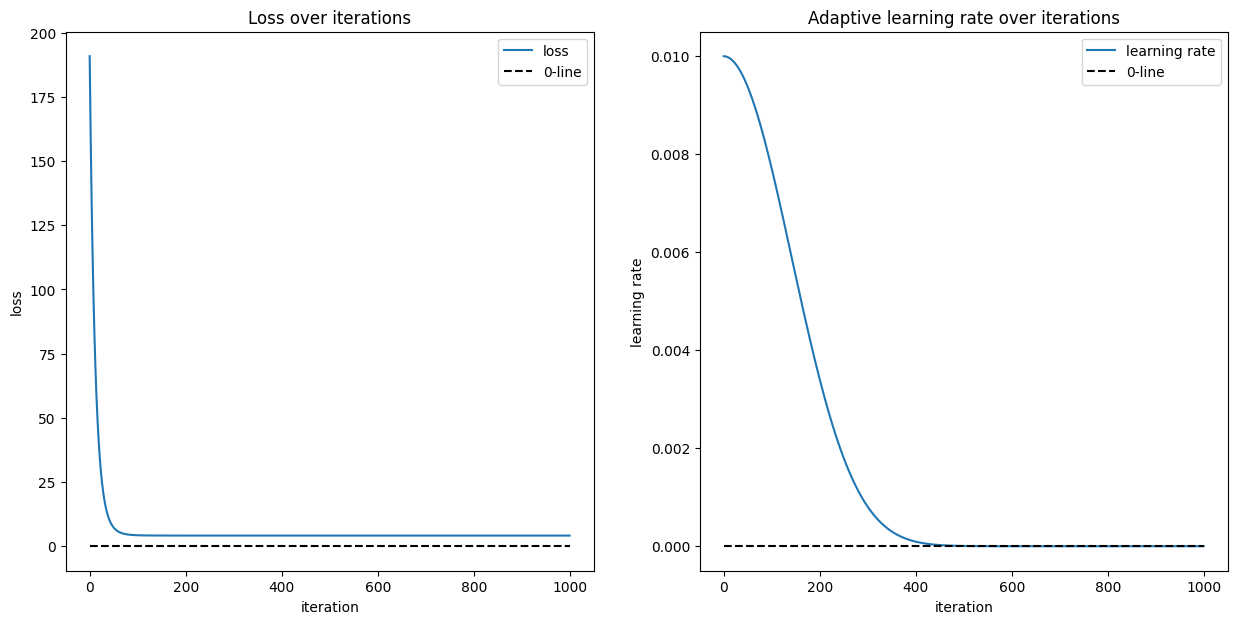

In [4]:
##################
### Linear Model
##################

class LinearModel( tf.Module ):
    
    '''
    Object defining a linear model with trainable vector weights (W) and scalar bias (b).

    Model Architecture:
    Yhat = <X, W> + b or Yhat_i = b + X_i1 W_1 + ... + X_i1 W_p

    Inheritance:
    - tf.Module : base class for all TensorFlow objects
    
    Attributes:
    - name : name of the model
    - p :    dimension of the input space

    Methods:
    - __init__ :      initializes the model
    - get_dimension : returns the dimension of the weight vector (W)
    - __call__ :      computes the output of the model given an input X
    '''

    def __init__(self, name = None, p = 1):
        super().__init__(name = name)

        '''
        Initializes the linear model with trainable vector weights (W) and scalar bias (b).

        Arguments:
        - self : instance of the LinearModel() class
        - name : name of the model
        - p :    dimension of the input space 
        '''

        # check if p is an positive integer
        # raise appropriate errors if not
        if not isinstance(p, int):
            raise ValueError(f"p {(p)} must be an integer")
        elif p < 1:
            raise ValueError(f"p {(p)} must be a positive integer.")

        self.W = tf.Variable(   tf.random.normal((p, )),  # p-dimensional weight vector
                                trainable = True,         # weight vector is trainable
                                name = 'W',               # name of the weight vector
                                dtype = tf.float32  )     # data type of the weight vector
        
        self.b = tf.Variable(   tf.random.normal((1, )),  # 1-dimensional bias scalar
                                trainable = True,         # bias scalar is trainable
                                name = 'b',               # name of the bias scalar
                                dtype = tf.float32  )     # data type of the bias scalar
        
    def get_dimension(self):
        
        '''
        Returns the dimension of the weight vector (W).

        input:
        - self : instance of the LinearModel() class

        output:
        - shape : shape of the weight vector (W) -> tuple
        '''
        shape = self.W.shape
        return shape
    
    def __call__(self, X, training = False):
        
        '''
        Computes the output of the linear model given an input X.

        Formula:
        Yhat = <X, W> + b or Yhat_i = b + X_i1 W_1 + ... + X_i1 W_p

        Arguments:
        - self :    instance of the LinearModel() class
        - X :       input data -> tf.Tensor of shape (n, p)
        - training: boolean flag to indicate if the model is in training mode -> default is False

        Returns:
        - lin_comb: linear combination of the input data X -> tf.Tensor of shape (1,) 
        '''
        
        lin_comb = tf.tensordot(X, self.W, 1) + self.b
        return lin_comb
    
#########################
### Testing Linear Model
#########################

linear_model = LinearModel(p = 3)
linear_model.W.assign([1.0, 1.0, 1.0])
linear_model.b.assign([1.0])
X = tf.constant([[0, 1, 2], [3, 4, 5]], dtype = tf.float32)
print("Testing linear_model:", linear_model(X))
print("\n")

###################
### Loss Function
###################

def loss(y_obsd, y_pred):

    '''
    Computes the mean squared error loss between the observed and predicted values. 
    
    Formula:
    1/n * sum_i (y_obsd_i - y_pred_i)^2

    Arguments:
    - y_obsd :  observed values -> tf.Tensor of shape (n,)
    - y_pred :   predicted values -> tf.Tensor of shape (n,)

    Returns:
    - MSE :     mean squared error loss -> tf.Tensor of shape (1,)
    '''

    MSE = tf.reduce_mean( tf.square(y_obsd - y_pred) )
    return MSE

def train(model, x, y, step_size):
    
    '''
    Updates the weights (W) and bias (b) of the linear model using the gradient descent algorithm.

    Arguments:
    - model :      linear model -> instance of the LinearModel() class
    - x :          input data -> tf.Tensor of shape (n, p)
    - y :          observed values -> tf.Tensor of shape (n,)
    - step_size :  step size for the gradient descent update -> float

    Returns:
    - None :       updates the weights and bias of the model in place
    '''
    
    # GradientTape() records the operations for automatic differentiation
    with tf.GradientTape() as t:
        current_loss = loss(y, model(x))
        
        # compute the gradients of the loss with respect to the weights and bias
        (dW, db) = t.gradient(current_loss, [model.W, model.b])
        model.W.assign_sub( step_size * dW )    # update the weights
        model.b.assign_sub( step_size * db )    # update the bias

################
### Load Data
################

xtrain = tf.convert_to_tensor(np.load('lm_X.npy'))  # load the predictor data
ytrain = tf.convert_to_tensor(np.load('lm_Y.npy'))  # load the response values

# print the shape and type of the input data and observed values
print(f"type(xtrain)={type(xtrain)}, xtrain.shape={xtrain.shape}")
print(f"type(ytrain)={type(ytrain)}, ytrain.shape={ytrain.shape}")
print("\n")


############################
### Adaptive Learning Rate
############################

def adaptive_learning_rate(initial_lr, curr_step, total_steps, decay_factor = 0.05):
    
    '''
    Computes the learning rate at the current step using an adaptive learning rate scheme.

    Formula:
    - initial_lr * (1 - (curr_step / total_steps))^decay_factor

    Arguments:
    - initial_lr :      initial learning rate -> float
    - curr_step :       current step in the optimization process -> int
    - total_steps :     total number of steps in the optimization process -> int
    - decay_factor :    decay factor for the learning rate -> float, default is 0.05

    Returns:
    - learning_rate :   learning rate at the current step -> float
    '''
    
    learning_rate = (initial_lr * (1 - (curr_step / total_steps))**decay_factor)
    return learning_rate

##################
### Training Loop
##################

# Initialize the linear model
lm = LinearModel(p = xtrain.shape[1])

nstep = 1000          # number of steps for training
lr = 0.01             # initial learning rate
losses = []           # list to store the loss at each step
learning_rates = []   # list to store the learning rate at each step

for i in range(nstep):

    lr = adaptive_learning_rate(initial_lr = lr, curr_step = i, total_steps = nstep)    # update learning rate
    train(lm, xtrain, ytrain, lr)                                                       # update weights and bias
    losses.append(loss(ytrain, lm(xtrain)))                                             # compute loss and store
    learning_rates.append(lr)                                                           # store learning rate

    # print the loss, learning rate, weights, and bias at every 200 steps
    if i % 200 == 0:
        print(f"Step = {i}")
        print(f"Learning rate = {lr}")
        print(f"Loss = {loss(ytrain, lm(xtrain))}")
        print(f"Weights (W) = {lm.W.numpy()}")
        print(f"Bias (b) = {lm.b.numpy()}")
        print('-----------------------------------------')

#####################
### Final Parameters
#####################

W_lm_trained = lm.W.numpy()
b_lm_trained = lm.b.numpy()

# print the final loss, learning rate, weights, and bias
print('\n')
print('#########################################')
print(f"Final loss = {loss(ytrain, lm(xtrain))}")         # final loss
print(f"Final learning rate = {lr}")                      # final learning rate
print(f"Final intercept (b) = {b_lm_trained}")            # final scalar bias (b)
print(f"Final slope (W) = {W_lm_trained}")                # final vector weights (W)
print('#########################################')
print('\n')

################################
### Comparing with true W and b
################################

true_W = tf.constant([1.0, 1.0, 2.0, 3.0, 5.0, 8.0], dtype = tf.float32)    # true weight vector
true_b = tf.constant(-1.0, dtype = tf.float32)                              # true bias scalar
lm_W_sqerr = tf.norm( true_W - lm.W )                                       # norm distance between true W and trained W
lm_b_sqerr = tf.norm( true_b - lm.b )                                       # norm distance between true b and trained b

# print the element-wise and norm distance between the true and trained weights and bias
print(f"Element-wise difference between true W and trained W: {tf.math.abs(true_W - lm.W)}")
print(f"Element-wise difference between true b and trained b: {tf.math.abs(true_b - lm.b)}")
print(f"Norm distance between true W and trained W: {lm_W_sqerr}")
print(f"Norm distance between true b and trained b: {lm_b_sqerr}")

###################
### Relevant Plots
###################

fig, axs = plt.subplots(1, 2, figsize = (15, 7))

axs[0].plot(losses, label = 'loss')
axs[0].plot([0, nstep], [0, 0], linestyle = '--', color = 'black', label = '0-line')
axs[0].set_xlabel('iteration')
axs[0].set_ylabel('loss')
axs[0].set_title('Loss over iterations')
axs[0].legend()

axs[1].plot(learning_rates, label = 'learning rate')
axs[1].plot([0, nstep], [0, 0], linestyle = '--', color = 'black', label = '0-line')
axs[1].set_xlabel('iteration')
axs[1].set_ylabel('learning rate')
axs[1].set_title('Adaptive learning rate over iterations')
axs[1].legend()

plt.savefig('lm_training.pdf')
plt.show()

## 3.) Training a Basic Neural Net in tf.keras (4 points, spent $\approx$ 50 minutes)

**In this problem, you’ll get your first exposure to training a neural net in TensorFlow Keras. Keras is a submodule of TensorFlow, newly incorporated in version 2, which makes it easy to build fairly complicated models. We will have an overview of some of the basics of neural nets in our last lecture of the semester, so you may want to wait until that lecture to tackle this, but it’s up to you.**

**Important: please complete these tutorials in a separate Jupyter notebook from the one in which you complete the rest of the assignment. This notebook should be in a file called `NetID.tutorials.ipynb`, where `NetID` is your NetID, in all lower-case letters.**

Completed the above and submitted as `ssudhir2.tutorials.ipynb`.

## 4.) Building and Training a Logistic Regression Model (5 points, spent $\approx$ 80 minutes)

**In this problem, you’ll use TensorFlow to build and train a logistic regression model, which we will discuss briefly in our last lecture. In this model, the binary response Y is distributed as a Bernoulli random variable with success parameter $\sigma(W^T X + b)$, where:**

$$
\sigma(z) = \frac{1}{1 + \text{exp}(-z)}
$$

**is the logistic function, $X$ and $W$ are vectors of the same dimension, and $b$ is a scalar.**

**We will use the tf.keras optimization framework to fit this model. Note that this is a different approach from the one we took in the linear regression problem earlier in this assignment.** 

**There, we simply computed the gradient and implemented gradient descent ourselves. That is fine for small models, but once we are trying to train larger, more complicated models, it’s better to make use of the machinery provided by TensorFlow.**

**Of course, logistic regression isn’t actually such a complicated model, but its use of a nonlinearity applied to the output of a linear transformation makes it, in a sense, the simplest neural network we can build, and it suffices to illustrate the basic challenges that arise when we go from simple linear regression to a nonlinear model with a more interesting loss function.**

#### 1.

**Define a class `LogisticModel` that encodes logistic regression for `p`-dimensional data. You will likely find it easiest to start from the code you wrote above for the `LinearModel` class above. Indeed, you might want to have `LogisticModel` inherit from `LinearModel`, though that is not required. This model should have `__init__` and `__call__` methods, as well as a method `get_dimension`, just like LinearModel.**

#### 2.

**Override the initialization method to take an optional argument `p`, and initialize `W` and `b` to be tensors with shapes `(p,)` and `(1,)`, respectively, with entries drawn independently from a standard normal. This optional argument should default to `p=1` and your initialization method should raise an appropriate error in the event that this argument is not a positive integer. You are free to follow an approach similar to that used in `LinearModel` or, if you prefer, you may use the Keras layers framework, which you saw lecture and in the tutorial.**

#### 3.

**Implement an additional method `get_dimension` that takes no arguments (other than `self`) and returns the data dimension (i.e., the initialization argument `p`). You are free to store `p` as a class attribute or read `p` from `self.W.shape`.**

#### 4.

**Implement the `__call__` method so that the input `x` is a `tf.Tensor` of shape `(n,p)`, where:**

* **`n` is a number of observations (not known ahead of time!)**

* **`p` is the dimension specified upon initialization.**

**That is, each row of `x` is a vector of `p` predictors. The output of the call should be a `tf.Tensor` of shape `(n,)`, corresponding to the output of the logistic regression model, evaluated on the rows of `x`. There is no need to perform error checking for this method. We will leave it to TensorFlow to yell at us if `x` is of the wrong type or the wrong shape when we try to multiply it.**

#### 5.

**The zip file at:**

<h5 align="center"> https://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/HW12_logistic.zip </h5>

**contains four Numpy `.npy` files that contain train and test data generated from a logistic model:**

* **`logistic_xtest.npy` : contains a 500-by-3 matrix whose rows are the independent variables (predictors) from the test set.**

* **`logistic_xtrain.npy` : contains a binary 500-dimensional vector of dependent variables (responses) from the test set.**

* **`logistic_ytest.npy` : contains a binary 2000-dimensional vector of dependent variables (responses) from the train set.**

**Download these four files and include them in your submission so that we can run your notebook without downloading the files again.**

#### 6.

**Initialize a `LogisticModel` object called `logreg`, with `p=3`. As a sanity check, if you have loaded `logistic_xtest.npy` into a variable called `logistic_xtest`, you should be able to call `logreg(logistic_xtest)` and get back a tensor with shape `TensorShape[500]`.**

#### 7.

**Following the demo code from lecture, define a loss object called `logreg_loss` that encodes the cross entropy between the output of the model and the observed class labels.**

#### 8.

**Define an optimizer object called `logreg_optimizer`. You are free to choose an optimizer as you see fit, and I encourage you to try different optimizers and experiment with the learning rate (see the discussion of the training loop, below). You will likely find that some optimizers perform better than others on this problem.**

#### 9.

**Define loss and accuracy objects (from the `tf.keras.metrics` submodule) for both the train and test sets. That is, create variables `train_loss`, `train_acc`, `test_loss` and `test_acc`, that encode the loss on the train and test data (measured according to average cross entropy) and the accuracy on the train and test data.**

#### 10.

**Define functions `train_step` and `test_step`, both of which take arguments `x` and `y`, in that order, where `x` is a Tensor of shape `(n,p)` that encodes a collection of `n` predictors (one per row) and `y` is a Tensor of shape `(n,)` that encodes the responses for the `n` predictors. `train_step` should use the `tf.GradientTape` pattern that we saw in lecture to compute a gradient step to update the parameters of the instance `logreg` that you created previously. Make sure that you use the `@tf.function` decorator so that your code runs more quickly.**

#### 11.

**Write a training loop that optimizes the parameters of the model stored in `logreg` based on the training data. You can use the test data as a dev set, if you like, to verify that your model is actually learning something. You are encouraged to play around with different choices of the number of training steps, the optimizer, the learning rate... For that matter, if you want to try a different loss function altogether, you are welcome to do so (but if you do, please use a different set of variable names for your experimental model— `logreg` and the code designed to work with that should still be fit according to cross entropy loss).**

**Note: this is comparatively noisy data. You are unlikely to be able to push the accuracy past about 0.75. That is fine.**

#### 12.

**Having fit `logreg` to the training data, what is the loss of your model on the test data? Store the answer as a float in a variable `logreg_test_loss`. Similarly, store the training data loss in a variable `logreg_train_loss`. How do they compare?**

#### 13.

**The training and test sets were, in reality, generated with:**

$$
W = (1, 0, −2), \quad b = 1
$$

**Write TensorFlow expressions to compute the squared error in recovering `W` and `b` separately. Store those errors in `logreg_W_sqerr` and `logreg_b_sqerr`.**

**`logreg_W_sqerr` should be the squared Frobenius norm of the error between your estimate and the truth. Note: you need only evaluate the error of your final estimates, not at every step of training.**

type(xtrain)=<class 'tensorflow.python.framework.ops.EagerTensor'>, xtrain.shape=(2000, 3)
type(ytrain)=<class 'tensorflow.python.framework.ops.EagerTensor'>, ytrain.shape=(2000,)
type(xtest)=<class 'tensorflow.python.framework.ops.EagerTensor'>, xtrain.shape=(500, 3)
type(ytest)=<class 'tensorflow.python.framework.ops.EagerTensor'>, ytrain.shape=(500,)


Testing LogisticModel(p = 3): (500,)


epoch = 0
loss = 1.0188416242599487
accuracy = 0.35546875
slope (W) = [ 0.9907248  -0.59928936  0.09627981]
intercept (b) = [-0.8949735]
-----------------------------------------
epoch = 10
loss = 0.5702183842658997
accuracy = 0.72802734375
slope (W) = [ 0.6701854  -0.03330322 -0.9967001 ]
intercept (b) = [0.28679842]
-----------------------------------------
epoch = 20
loss = 0.5099101662635803
accuracy = 0.7529296875
slope (W) = [ 0.7876832   0.00419607 -1.5333314 ]
intercept (b) = [0.78912944]
-----------------------------------------
epoch = 30
loss = 0.5021214485168457
accuracy = 0.752929687

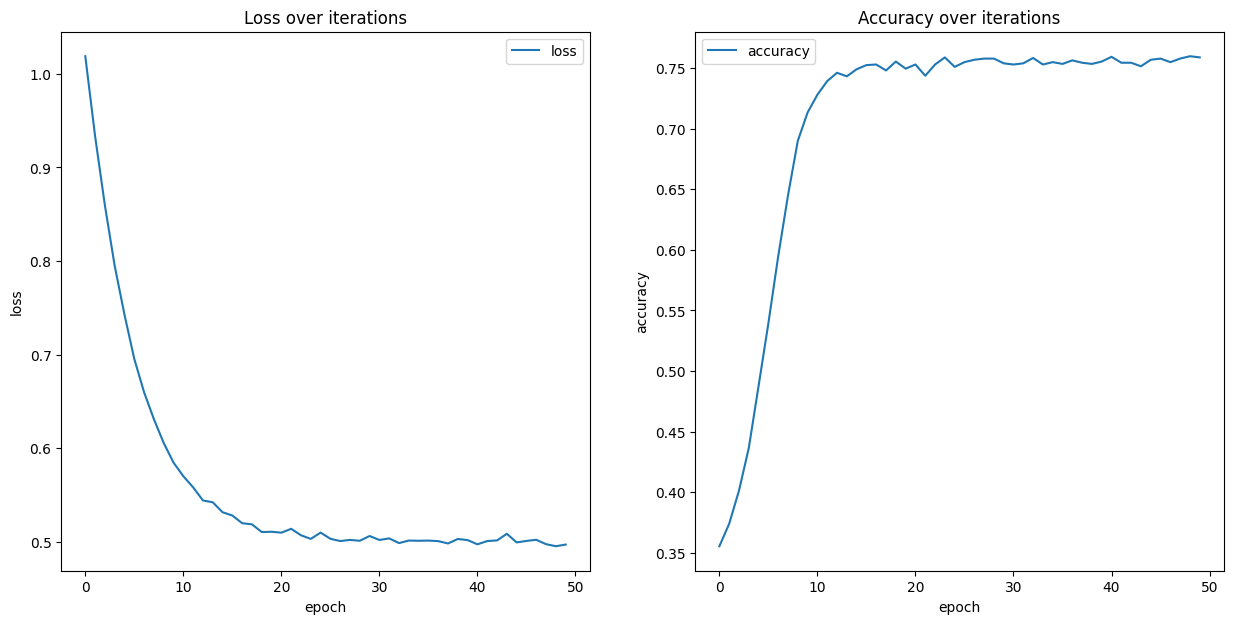

In [5]:
####################
### Logistic Model
####################

class LogisticModel( LinearModel ):

    '''
    Object defining a logistic model with trainable vector weights (W) and scalar bias (b). 

    Model Architecture:
    Yhat = sigmoid(<X, W> + b) or Yhat_i = sigmoid(b + X_i1 W_1 + ... + X_i1 W_p)

    Inheritance:
    - LinearModel : base class for the LogisticModel() class

    Attributes:
    - name : name of the model
    - p :    dimension of the input space

    Methods:
    - __init__ :      initializes the model
    - get_dimension : returns the dimension of the weight vector (W)
    - __call__ :      computes the output of the model given an input X
    '''
    
    def __init__(self, name = None, p = 1):
        # call the constructor of the LinearModel() class
        super().__init__(name = name, p = p)

    def get_dimension(self):
        # call the get_dimension() method of the LinearModel() class
        return super().get_dimension()

    def __call__(self, X, training = False):
        # call the __call__() method of the LinearModel() class
        # apply the sigmoid activation function to the output
        return tf.nn.sigmoid( super().__call__(X) )
    
#####################
### Hyperparameters
#####################

batch_size = 64         # batch size for training
learning_rate = 0.005   # learning rate for optimization
epochs = 50             # number of epochs for training
losses = []             # list to store the loss at each epoch
accuracies = []         # list to store the accuracy at each epoch

logreg_loss = tf.keras.losses.BinaryCrossentropy()                         # binary cross-entropy loss
logreg_optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate) # Adam optimizer

train_loss = tf.keras.metrics.Mean(name = 'train_loss')             # training loss
train_acc = tf.keras.metrics.BinaryAccuracy(name = 'train_acc')     # training accuracy
test_loss = tf.keras.metrics.Mean(name = 'test_loss')               # test loss
test_acc = tf.keras.metrics.BinaryAccuracy(name = 'test_acc')       # test accuracy

##############
### Load Data
##############

# load the training and test data (X), and convert them to tensors
logistic_xtrain = tf.convert_to_tensor(np.load('logistic_xtrain.npy'))
logistic_xtest = tf.convert_to_tensor(np.load('logistic_xtest.npy'))

# load the training and test labels (Y), and convert them to tensors
logistic_ytrain = tf.convert_to_tensor(np.load('logistic_ytrain.npy'))
logistic_ytest = tf.convert_to_tensor(np.load('logistic_ytest.npy'))

# print the shapes of the training and test data
print(f"type(xtrain)={type(logistic_xtrain)}, xtrain.shape={logistic_xtrain.shape}")
print(f"type(ytrain)={type(logistic_ytrain)}, ytrain.shape={logistic_ytrain.shape}")
print(f"type(xtest)={type(logistic_xtest)}, xtrain.shape={logistic_xtest.shape}")
print(f"type(ytest)={type(logistic_ytest)}, ytrain.shape={logistic_ytest.shape}")
print("\n")

#####################
### Data Preparation
#####################

# shuffle and batch the training data
logistic_train = tf.data.Dataset.from_tensor_slices((logistic_xtrain, logistic_ytrain))
logistic_train = logistic_train.shuffle(buffer_size = len(logistic_ytrain)).batch(batch_size)

# shuffle and batch the test data
logistic_test = tf.data.Dataset.from_tensor_slices((logistic_xtest, logistic_ytest))
logistic_test = logistic_test.shuffle(buffer_size = len(logistic_ytest)).batch(batch_size)

###########################
### Testing Logistic Model
###########################

logreg = LogisticModel(p = 3)
print("Testing LogisticModel(p = 3):", logreg(logistic_xtest).shape)
print("\n")

###########################
### Training and Test Step
###########################

@tf.function
def train_step(logreg, x, y, logreg_optimizer):
    
    '''
    Performs a single optimization step for the logistic regression model.

    Arguments:
    - logreg :      logistic regression model -> instance of the LogisticModel() class
    - x :           input data -> tf.Tensor of shape (n, p)
    - y :           observed values -> tf.Tensor of shape (n,)
    - logreg_optimizer: optimizer object -> instance of the tf.keras.optimizers.[name]() class

    Returns:
    - current_loss : current loss value -> tf.Tensor of shape (1,)
    '''
    
    # GradientTape() records the operations for automatic differentiation
    with tf.GradientTape() as t:
        ypred = logreg(x)
        current_loss = logreg_loss(y, ypred)

    # compute the gradients of the loss with respect to the weights and bias
    gradients = t.gradient(current_loss, logreg.trainable_variables)                  # compute the gradients
    logreg_optimizer.apply_gradients( zip(gradients, logreg.trainable_variables) )    # apply the gradients

    train_loss.update_state(current_loss)  # update the training loss
    train_acc.update_state(y, logreg(x))   # update the training accuracy

    return current_loss

@tf.function
def test_step(x, y):

    '''
    Computes the loss and accuracy for the logistic regression model on the test data.
    Note: absolutely no optimization is performed in this function.

    Arguments:
    - x :           input data -> tf.Tensor of shape (n, p)
    - y :           observed values -> tf.Tensor of shape (n,)
    
    Returns:
    - current_loss : current loss value -> tf.Tensor of shape (1,)
    '''

    ypred = logreg(x)                      # compute the predicted values
    current_loss = logreg_loss(y, ypred)   # compute the loss
    
    test_loss.update_state(current_loss)   # update the test loss
    test_acc.update_state(y, ypred)        # update the test accuracy

    return current_loss

##################
### Training Loop
##################

for epoch in range(epochs):

    train_loss.reset_state()
    train_acc.reset_state()
    test_loss.reset_state()
    test_acc.reset_state()

    for x_batch, y_batch in logistic_train:
        train_step(logreg, x_batch, y_batch, logreg_optimizer)

    for x_batch, y_batch in logistic_test:
        test_step(x_batch, y_batch)
    
    if epoch % 10 == 0:
        print(f"epoch = {epoch}")
        print(f"loss = {train_loss.result()}")
        print(f"accuracy = {train_acc.result()}")
        print(f"slope (W) = {logreg.W.numpy()}")
        print(f"intercept (b) = {logreg.b.numpy()}")
        print('-----------------------------------------')
    
    losses.append(train_loss.result())
    accuracies.append(train_acc.result())

#####################
### Final Parameters
#####################

W_logreg_trained = logreg.W.numpy()
b_logreg_trained = logreg.b.numpy()

print("\n")
print('#########################################')
print(f"Final loss = {train_loss.result()}")
print(f"Final accuracy = {train_acc.result()}")
print(f"Final slope (W) = {W_logreg_trained}")
print(f"Final intercept (b) = {b_logreg_trained}")
print('#########################################')
print("\n")

###################
### Test Accuracy
###################

logreg_test_loss = test_loss.result()
logreg_train_loss = train_loss.result()

print(f"Train Loss = {logreg_train_loss}, Test Loss = {logreg_test_loss}")
print(f"Train Accuracy = {train_acc.result()}, Test Accuracy = {test_acc.result()}")
print(f"Loss Difference = {logreg_train_loss - logreg_test_loss}, Acurracy Difference = {train_acc.result() - test_acc.result()}")
print("\n")

################################
### Comparing with true W and b
################################

true_W = tf.constant([1.0, 0.0, -2.0], dtype = tf.float32)
true_b = tf.constant(1.0, dtype = tf.float32)
logreg_W_sqerr = tf.norm( true_W - logreg.W )**2
logreg_b_sqerr = tf.norm( true_b - logreg.b )**2
print(f"Element-wise absolute difference between true W and trained W: {tf.math.abs(true_W - logreg.W)}")
print(f"Element-wise absolute difference between true b and trained b: {tf.math.abs(true_b - logreg.b)}")
print(f"logreg_W_sqerr = {logreg_W_sqerr}")
print(f"logreg_b_sqerr = {logreg_b_sqerr}")

###################
### Relevant Plots
###################

fig, axs = plt.subplots(1, 2, figsize = (15, 7))
axs[0].plot(losses, label = 'loss')
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].set_title('Loss over iterations')
axs[0].legend()

axs[1].plot(accuracies, label = 'accuracy')
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].set_title('Accuracy over iterations')
axs[1].legend()

plt.savefig('logreg_training.pdf')
plt.show()

We can see that the performace on training data and test data is very similar, with very little difference between the train and test loss and accuracy respectively. Furthermore, the model weights and bias very closely converged to the true weights and bias. This implies that our model performs well on both seen and unseen data.

## 5.) Training a Neural Net on GCP (4 points, spent $\approx$ 60 minutes)

**This problem will get you more practice interacting with both TensorFlow and Google Cloud Platform. The following tutorial is part of Google’s “Cloud Skills Boost” materials.**

<h5 align="center"> https://www.cloudskillsboost.google/focuses/21599?parent=catalog </h5>

**It is meant to be a timed portion of a multi-lesson sequence of labs, but we are only going to do this one lab in the sequence. In addition, these labs are meant to be run in a timed environment, where the timer is essentially counting down the time on a temporary free GCP account. We don’t need that free account, because we have GCP credits. Do not at any time click the “Start lab” button. You don’t need it, and it will make it harder for you to make sure your assignment gets graded correctly.**

**Before starting the tutorial, make sure that your current project is set to the project you have used for Homeworks 10 and 11. Recall that this project should be named `NetID-stat606s24`, where NetID is your Wisconsin NetID in all lower-case letters.**

**Create a bucket named `NetID-stat606s24-hw12`, where `NetID` is your Wisconsin `NetID` in all lower-case letters. All settings should be the same as the buckets you created for Homeworks 10 and 11.**

Completed the above procedure.

**Follow the tutorial at the link above, which will walk you through setting up a Jupyter notebook running on a GCP VM. Then you will write and run code in that notebook to train a model for image classification, and subsequently deploy the model so that we can submit new images to be classified. Don’t forget to make sure that you first open up a Google Cloud Console shell and verify that you have set the current project to your `NetID-stat606s24` project, and make sure that you specify your bucket in the Jupyter notebook to be your `NetID-stat606s24-hw12` bucket. A side effect of this tutorial will be the creation of a TensorFlow model in your bucket, which we will use to verify that you completed the tutorial.**

#### Task 1. Enable Google Cloud services

**1. In Cloud Shell, use `gcloud` to enable the services used in the lab:**

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gcloud services enable \
  compute.googleapis.com \
  iam.googleapis.com \
  iamcredentials.googleapis.com \
  monitoring.googleapis.com \
  logging.googleapis.com \
  notebooks.googleapis.com \
  aiplatform.googleapis.com \
  bigquery.googleapis.com \
  artifactregistry.googleapis.com \
  cloudbuild.googleapis.com \
  container.googleapis.com
Operation "operations/acat.p2-89254757867-85203785-582b-47a2-9d0d-1dd7d0303c47" finished successfully.
```

**2. Create a custom service account:**

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ SERVICE_ACCOUNT_ID=vertex-custom-training-sa
gcloud iam service-accounts create $SERVICE_ACCOUNT_ID  \
    --description="A custom service account for Vertex custom training" \
    --display-name="Vertex AI Custom Training"
Created service account [vertex-custom-training-sa].
```

**3. Set the Project ID environment variable:**

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ PROJECT_ID=$(gcloud config get-value core/project)
Your active configuration is: [cloudshell-9655]
```

**4. Grant you service account the `aiplatform.user` role:**

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gcloud projects add-iam-policy-binding $PROJECT_ID \
    --member=serviceAccount:$SERVICE_ACCOUNT_ID@$PROJECT_ID.iam.gserviceaccount.com \
    --role="roles/aiplatform.user"
Updated IAM policy for project [ssudhir2-stat606s24].
bindings:
- members:
  - deleted:serviceAccount:vertex-custom-training-sa@ssudhir2-stat606s24.iam.gserviceaccount.com?uid=109495042185090997102
  - serviceAccount:vertex-custom-training-sa@ssudhir2-stat606s24.iam.gserviceaccount.com
  role: roles/aiplatform.user
- members:
  - serviceAccount:89254757867@cloudbuild.gserviceaccount.com
  role: roles/cloudbuild.builds.builder
- members:
  - serviceAccount:service-89254757867@gcp-sa-cloudbuild.iam.gserviceaccount.com
  role: roles/cloudbuild.serviceAgent
- members:
  - serviceAccount:service-89254757867@compute-system.iam.gserviceaccount.com
  role: roles/compute.serviceAgent
- members:
  - serviceAccount:service-89254757867@container-engine-robot.iam.gserviceaccount.com
  role: roles/container.serviceAgent
- members:
  - serviceAccount:service-89254757867@containerregistry.iam.gserviceaccount.com
  role: roles/containerregistry.ServiceAgent
- members:
  - serviceAccount:service-89254757867@dataproc-accounts.iam.gserviceaccount.com
  role: roles/dataproc.serviceAgent
- members:
  - serviceAccount:89254757867-compute@developer.gserviceaccount.com
  - serviceAccount:89254757867@cloudservices.gserviceaccount.com
  role: roles/editor
- members:
  - serviceAccount:service-89254757867@gcp-sa-notebooks.iam.gserviceaccount.com
  role: roles/notebooks.serviceAgent
- members:
  - user:jjia39@wisc.edu
  - user:kdlevin@wisc.edu
  - user:ssudhir2@wisc.edu
  role: roles/owner
- members:
  - serviceAccount:service-89254757867@gcp-sa-pubsub.iam.gserviceaccount.com
  role: roles/pubsub.serviceAgent
etag: BwYXaPsYuys=
version: 1
```

#### Task 2. Deploy Vertex notebook instance

**To create and launch a Vertex AI Workbench notebook:**

* **In the `Navigation Menu` icon, click `Vertex AI` > `Workbench`.**

Completed the above procedure.

* **On the `Workbench` page, click `Enable Notebooks API` (if it isn't enable yet).**

Completed the above procedure.

* **Click on `User-Managed Notebooks` tab then, click `Create New`.**

Completed the above procedure.

* **In the `New instance` menu, choose `TensorFlow Enterprise 2.11` in `Environment`.**

Completed the above procedure. Chose `TensorFlow Enterprise 2.15 (Intel MKL-DNN/MKL)`

* **Name the notebook.**

Completed the above procedure. Named `ssudhir2-stat606s24-hw12`.

* **Set `Region` and `Zone` within the designated region.**

Completed the above procedure. Region is `us-east1 (South Carolina)` and Zone `us-east1-c`.

* **Click `Advanced Options` to edit the instance properties.**

Completed the above procedure.

* **Click `Machine type` and then select `e2-standard-2` for Machine type.**

Completed the above procedure.

* **Leave the remaining fields at their default and click `Create`.**

Completed the above procedure.

**After a few minutes, the `Workbench` page lists your instance, followed by `Open JupyterLab`.**

* **Click `Open JupyterLab` to open JupyterLab in a new tab. If you get a message saying beatrix jupyterlab needs to be included in the build, just ignore it.**

Completed the above procedure.

#### Task 3. Clone the lab repository

**Next, you'll clone the `training-data-analyst` notebook in your JupyterLab instance.**

* **In JupyterLab, click the `Terminal` icon to open a new terminal.**

Completed the above procedure.

* **To clone the `training-data-analyst` Github repository, type in the following command, and press `Enter`:**

```bash
(base) jupyter@ssudhir2-stat606s24-hw12:~$ git clone https://github.com/GoogleCloudPlatform/training-data-analyst
Cloning into 'training-data-analyst'...
remote: Enumerating objects: 64800, done.
remote: Counting objects: 100% (259/259), done.
remote: Compressing objects: 100% (172/172), done.
Receiving objects:                                
remote: Total 64800 (delta 136), reused 176 (delta 85), pack-reused 64541
  100% (64800/64800), 698.20 MiB | 28.03 MiB/s, done.
Resolving deltas: 100% (41358/41358), done.
Updating files: 100% (12864/12864), done.
```

* **To confirm that you have cloned the repository, double-click the `training-data-analyst` directory and confirm that you can see its contents.**

Confirmed that all contents are visible.

**Navigate to the lab notebook**

* **In the left panel, navigate to the `training-data-analyst/self-paced-labs/vertex-ai/vertex-distributed-tensorflow` folder.**

Completed the above procedure.

* **Click the `Qwiklab_Running_Distributed_TensorFlow_using_Vertex_AI.ipynbfile` to open it in the right window.**

Completed the above procedure.

* **Continue the lab in the notebook, and run each cell by clicking the `Run` icon at the top of the screen. Alternatively, you can execute the code in a cell with `SHIFT + ENTER`.**

Completed the above procedure.

* **Read the narrative and make sure you understand what's happening in each cell.**

Completed the above procedure.

* **In order to view the status of training and deployment on Vertex AI, you can follow the instructions in the notebook containing illustrations.**

Completed the above procedure.

**A few important points to be careful of:**

* **When the tutorial asks you to specify a bucket name, please be sure that you use the bucket for this homework, `NetID-stat606s24-hw12`.**

* **At the end of the tutorial, in the last section, titled “Cleaning up”, the instructions (and the code in the notebook) tell you to delete the job, model, endpoint and storage bucket. *Please do not delete either your model or your bucket, as these are part of your submission*. As part of grading your submission, we will look for a model in your bucket that behaves as expected given the tutorial instructions. If you delete this model and/or the bucket containing it, you will not be able to receive credit for this problem. Therefore, you should modify the last block of code in the tutorial Jupyter notebook so that it deletes the job and endpoint, but not the bucket or the model it contains.**

* **Make sure that you do delete the job and the endpoint, so as to avoid burning through all your credits. You should verify that you can see files in your bucket corresponding to your trained model, and verify that you do not see any running VMs associated to this tutorial in your VM Instances tab, and that you do not see any endpoints in the Vertex AI → Endpoints console.**

* **After closing your browser tab running the GCP Jupyter notebook, make sure you also delete the notebook itself from the Vertex AI → Workbench console and delete the VM that the notebook was running in. This will not be accomplished by the code in the notebook itself; you will have to delete it yourself in the VM Instances console.**

Completed all of the above and submitted in `gs://ssudhir2-stat606s24-hw12/`.